### 10. Simulación BCI (EEG sintético y control)
* Señales EEG reales o sintéticas; bandas Alpha/Beta.
* Filtros pasa banda con scipy.signal.
* Umbrales de control y acciones visuales.
* Interfaz interactiva con PyGame/Tkinter.

pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


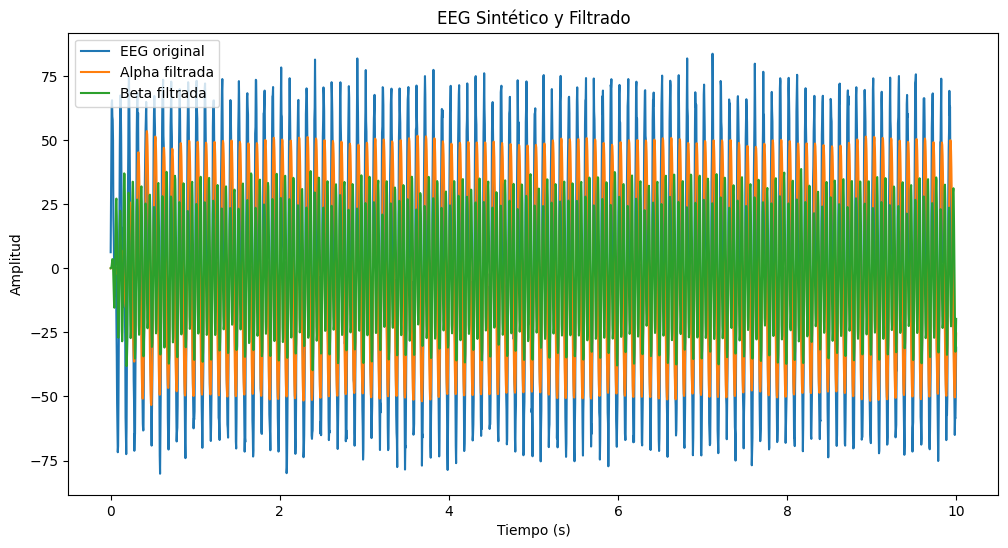

In [ ]:
# ==============================================
# Simulación BCI con EEG sintético
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter
import pygame
from pygame.locals import *

# --- Configuración inicial ---
fs = 250  # Frecuencia de muestreo (Hz)
t = np.arange(0, 10, 1/fs)  # 10 segundos de datos

# --- Generar señales EEG sintéticas ---
# Alpha: 8-12 Hz
alpha = 50 * np.sin(2 * np.pi * 10 * t)
# Beta: 13-30 Hz
beta = 30 * np.sin(2 * np.pi * 20 * t)
# Señal combinada con ruido
eeg_signal = alpha + beta + 5*np.random.randn(len(t))

# --- Funciones de filtro pasa banda ---
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

# Filtrar señales
alpha_filt = bandpass_filter(eeg_signal, 8, 12, fs)
beta_filt = bandpass_filter(eeg_signal, 13, 30, fs)

# --- Umbrales de control ---
alpha_thresh = np.mean(alpha_filt) + 2*np.std(alpha_filt)
beta_thresh = np.mean(beta_filt) + 2*np.std(beta_filt)

# --- Inicializar pygame ---
pygame.init()
screen = pygame.display.set_mode((400, 400))
pygame.display.set_caption("Simulación BCI")
clock = pygame.time.Clock()

# --- Variables visuales ---
color = (0, 0, 0)
running = True
i = 0
dt = int(1000/fs)  # ms por muestra

while running and i < len(t):
    for event in pygame.event.get():
        if event.type == QUIT:
            running = False

    # Control visual: cambiar color según amplitud filtrada
    if alpha_filt[i] > alpha_thresh:
        color = (0, 0, 255)  # Azul si Alpha alta
    elif beta_filt[i] > beta_thresh:
        color = (255, 0, 0)  # Rojo si Beta alta
    else:
        color = (0, 0, 0)  # Negro si ninguna supera umbral

    screen.fill(color)
    pygame.display.flip()
    clock.tick(1000/dt)
    i += 1

pygame.quit()

# --- Graficar señal EEG y filtrada ---
plt.figure(figsize=(12,6))
plt.plot(t, eeg_signal, label='EEG original')
plt.plot(t, alpha_filt, label='Alpha filtrada')
plt.plot(t, beta_filt, label='Beta filtrada')
plt.legend()
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('EEG Sintético y Filtrado')
plt.show()


🧠 Punto 10 – Simulación BCI (EEG sintético y control)

Este experimento implementa una simulación básica de una interfaz cerebro–computadora (BCI) utilizando señales EEG sintéticas.
El objetivo es representar cómo la actividad cerebral, en distintas bandas de frecuencia, puede emplearse para controlar una respuesta visual.


Descripción general del proceso:

Configuración inicial:
Se define la frecuencia de muestreo y el intervalo temporal para la simulación de la señal EEG.

Generación de señales EEG sintéticas:
Se crean ondas senoidales que representan las bandas Alpha (8–12 Hz) y Beta (13–30 Hz), combinadas con ruido aleatorio para imitar la variabilidad de una señal cerebral real.


Filtrado pasa banda:
Se implementan funciones Butterworth para aislar las componentes Alpha y Beta de la señal total, simulando el proceso de extracción de frecuencias específicas en un análisis EEG real.


Definición de umbrales de control:
A partir de la amplitud promedio de las señales filtradas, se establecen umbrales que determinan cuándo la actividad cerebral es suficientemente intensa como para generar una acción visual.


Visualización interactiva con Pygame:
Se abre una ventana que cambia de color según la banda predominante:

Azul → predominio de la actividad Alpha.

Rojo → predominio de la actividad Beta.

Negro → sin activación relevante.

Este comportamiento simula un sistema donde las variaciones EEG controlan la interfaz visual.

Ejecución y cierre:

Durante la simulación, se recorren los valores de la señal EEG en tiempo real, se aplican los filtros y se actualiza la interfaz visual de acuerdo con los resultados.

Al finalizar, Pygame se cierra automáticamente y se grafican las señales original y filtradas para observación comparativa.

Conclusión:

El sistema demuestra cómo las señales cerebrales, incluso simuladas, pueden emplearse para activar respuestas visuales dinámicas.
Este enfoque ilustra los principios fundamentales de una BCI: adquisición, filtrado, interpretación y control.

Aunque se trata de una simulación, el modelo sienta las bases para explorar futuras integraciones con datos EEG reales o sistemas multimodales que combinen control neuronal y estímulos visuales interactivos.